<a href="https://colab.research.google.com/github/ariandit/user_arian/blob/master/Testing%20(%20Yelp%2C%20ADHD%2C%20YOLO%20).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEMBACA DATASET BUSINESS (Untuk Analisis Geo-Spatial & Atribut)

In [ ]:
from google.colab import drive
import os
import pandas as pd
import json

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Update PATH sesuai dengan lokasi folder baru Anda
GDRIVE_FOLDER_PATH = '/content/drive/MyDrive/METODOLOGI DS/Yelp_Dataset'

print("==================================================")
print("Memeriksa isi folder di Google Drive...")
try:
    files = os.listdir(GDRIVE_FOLDER_PATH)
    print("BERHASIL TERHUBUNG! File yang ditemukan di folder Anda:")
    for f in files:
        print(f" - {f}")
except FileNotFoundError:
    print(f"[ERROR] Folder MASIH TIDAK ditemukan di path: '{GDRIVE_FOLDER_PATH}'")
    print("Silakan cek kembali tulisan besar/kecil dan spasi nama folder Anda di Google Drive.")
print("==================================================")

# Fungsi aman untuk membaca data (agar RAM tidak crash dan toleran terhadap baris yang error/corrupt)
def baca_data_yelp_satuan(file_name, limit_baris=10000):
    file_path = os.path.join(GDRIVE_FOLDER_PATH, file_name)
    if not os.path.exists(file_path):
        print(f"[ERROR] File '{file_name}' tidak ditemukan di folder.")
        return None

    data = []
    sukses, error = 0, 0
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= limit_baris:
                break
            try:
                data.append(json.loads(line))
                sukses += 1
            except:
                error += 1
                continue
    df = pd.DataFrame(data)
    print(f"-> {file_name} Berhasil Dimuat: {sukses} baris | Rusak/Dilewati: {error} baris.")
    return df

Mounted at /content/drive
Memeriksa isi folder di Google Drive...
BERHASIL TERHUBUNG! File yang ditemukan di folder Anda:
 - yelp_academic_dataset_business.json
 - yelp_academic_dataset_review.json
 - yelp_academic_dataset_user.json
 - yelp_academic_dataset_checkin.json
 - yelp_academic_dataset_tip.json
 - Yelp_Dataset_Challenge_Terms_round_5.pdf
 - Dataset_Challenge_Academic_Dataset_Agreement.pdf


In [ ]:
# Memuat data business (Dibatasi 10.000 baris agar ringan)
df_business = baca_data_yelp_satuan('yelp_academic_dataset_business.json', limit_baris=10000)

if df_business is not None:
    print("\n--- 1. PREVIEW DATA BUSINESS (3 BARIS PERTAMA) ---")
    display(df_business.head(3))

    print("\n--- 2. INFORMASI STRUKTUR DATA & KOLOM ---")
    df_business.info()

    print("\n--- 3. ANALISIS KOTA DENGAN BISNIS TERBANYAK (DATA UNDERSTANDING) ---")
    print(df_business['city'].value_counts().head(5))

    print("\n--- 4. STATISTIK DESKRIPTIF RATING BINTANG (STARS) ---")
    print(df_business['stars'].describe())

-> yelp_academic_dataset_business.json Berhasil Dimuat: 10000 baris | Rusak/Dilewati: 0 baris.

--- 1. PREVIEW DATA BUSINESS (3 BARIS PERTAMA) ---


,business_id,full_address,hours,open,categories,city,review_count,name,neighborhoods,longitude,state,stars,latitude,attributes,type
0,vcNAWiLM4dR7D2nwwJ7nCA,"4840 E Indian School Rd\nSte 101\nPhoenix, AZ ...","{'Tuesday': {'close': '17:00', 'open': '08:00'...",True,"[Doctors, Health & Medical]",Phoenix,9,"Eric Goldberg, MD",[],-111.983758,AZ,3.5,33.499313,{'By Appointment Only': True},business
1,UsFtqoBl7naz8AVUBZMjQQ,"202 McClure St\nDravosburg, PA 15034",{},True,[Nightlife],Dravosburg,4,Clancy's Pub,[],-79.886930,PA,3.5,40.350519,"{'Happy Hour': True, 'Accepts Credit Cards': T...",business
2,cE27W9VPgO88Qxe4ol6y_g,"1530 Hamilton Rd\nBethel Park, PA 15234",{},False,"[Active Life, Mini Golf, Golf]",Bethel Park,5,Cool Springs Golf Center,[],-80.015910,PA,2.5,40.356896,{'Good for Kids': True},business



--- 2. INFORMASI STRUKTUR DATA & KOLOM ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   business_id    10000 non-null  object 
 1   full_address   10000 non-null  object 
 2   hours          10000 non-null  object 
 3   open           10000 non-null  bool   
 4   categories     10000 non-null  object 
 5   city           10000 non-null  object 
 6   review_count   10000 non-null  int64  
 7   name           10000 non-null  object 
 8   neighborhoods  10000 non-null  object 
 9   longitude      10000 non-null  float64
 10  state          10000 non-null  object 
 11  stars          10000 non-null  float64
 12  latitude       10000 non-null  float64
 13  attributes     10000 non-null  object 
 14  type           10000 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(10)
memory usage: 1.1+ MB

--- 3. ANALISIS KOTA DENGAN

In [ ]:
# Memuat data ulasan singkat/tip
df_tip = baca_data_yelp_satuan('yelp_academic_dataset_tip.json', limit_baris=10000)

if df_tip is not None:
    print("\n--- 1. PREVIEW DATA TIP / USER KOMENTAR (3 BARIS PERTAMA) ---")
    display(df_tip.head(3))

    print("\n--- 2. CONTOH TEKS KOMENTAR USER (DATA TIDAK TERSTRUKTUR) ---")
    for i, teks in enumerate(df_tip['text'].head(5)):
        print(f"Komentar {i+1}: {teks}")

    print("\n--- 3. STATISTIK LIKES PADA KOMENTAR ---")
    print(df_tip['likes'].describe())

-> yelp_academic_dataset_tip.json Berhasil Dimuat: 10000 baris | Rusak/Dilewati: 0 baris.

--- 1. PREVIEW DATA TIP / USER KOMENTAR (3 BARIS PERTAMA) ---


,user_id,text,business_id,likes,date,type
0,-6rEfobYjMxpUWLNxszaxQ,Don't waste your time.,cE27W9VPgO88Qxe4ol6y_g,0,2013-04-18,tip
1,EZ0r9dKKtEGVx2CdnowPCw,Your GPS will not allow you to find this place...,mVHrayjG3uZ_RLHkLj-AMg,0,2013-01-06,tip
2,xb6zEQCw9I-Gl0g06e1KsQ,Great drink specials!,KayYbHCt-RkbGcPdGOThNg,0,2013-12-03,tip



--- 2. CONTOH TEKS KOMENTAR USER (DATA TIDAK TERSTRUKTUR) ---
Komentar 1: Don't waste your time.
Komentar 2: Your GPS will not allow you to find this place. Put Rankin police department in instead. They are directly across the street.
Komentar 3: Great drink specials!
Komentar 4: Sarah rocks! Best waitress here! Be sure to get her and compliment her glasses.
Komentar 5: Decent selection of more than just bar food. 

Jumbo fish sandwich is aptly named. 

Seem to be generous with the pour.

--- 3. STATISTIK LIKES PADA KOMENTAR ---
count    10000.000000
mean         0.011800
std          0.110734
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: likes, dtype: float64


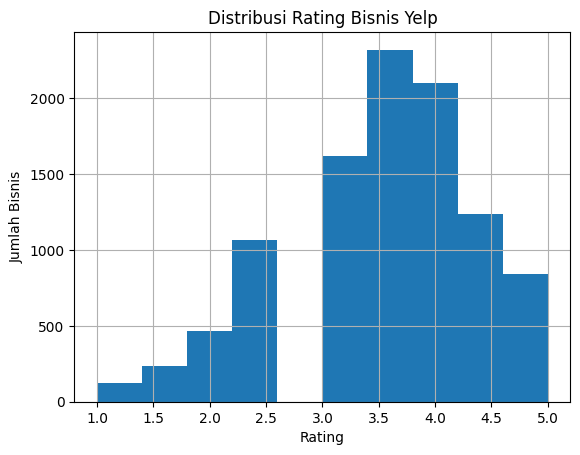

In [ ]:
#gambar baru
import matplotlib.pyplot as plt

df_business['stars'].hist(bins=10)

plt.title("Distribusi Rating Bisnis Yelp")
plt.xlabel("Rating")
plt.ylabel("Jumlah Bisnis")

plt.show()

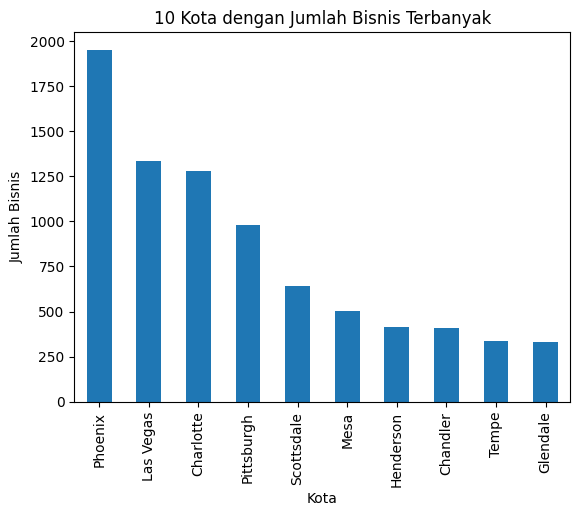

In [ ]:
top_city = df_business['city'].value_counts().head(10)

top_city.plot(kind='bar')

plt.title("10 Kota dengan Jumlah Bisnis Terbanyak")
plt.xlabel("Kota")
plt.ylabel("Jumlah Bisnis")

plt.show()

In [ ]:
# Memuat data check-in kedatangan konsumen
df_checkin = baca_data_yelp_satuan('yelp_academic_dataset_checkin.json', limit_baris=10000)

if df_checkin is not None:
    print("\n--- 1. PREVIEW DATA CHECKIN (3 BARIS PERTAMA) ---")
    display(df_checkin.head(3))

    print("\n--- 2. STRUKTUR PASANGAN KEY-VALUE PADA CHECKIN INFO ---")
    # Menampilkan detail checkin_info baris pertama (Format: "Jam-Hari": Jumlah Kunjungan)
    print(json.dumps(df_checkin['checkin_info'].iloc[0], indent=4)[:300] + "\n... dst")

-> yelp_academic_dataset_checkin.json Berhasil Dimuat: 10000 baris | Rusak/Dilewati: 0 baris.

--- 1. PREVIEW DATA CHECKIN (3 BARIS PERTAMA) ---


,checkin_info,type,business_id
0,"{'9-5': 1, '7-5': 1, '13-3': 1, '17-6': 1, '13...",checkin,cE27W9VPgO88Qxe4ol6y_g
1,"{'22-5': 1, '9-5': 1, '15-1': 1, '15-4': 1, '1...",checkin,mVHrayjG3uZ_RLHkLj-AMg
2,"{'9-1': 1, '18-3': 1, '15-1': 1, '15-2': 1, '8...",checkin,KayYbHCt-RkbGcPdGOThNg



--- 2. STRUKTUR PASANGAN KEY-VALUE PADA CHECKIN INFO ---
{
    "9-5": 1,
    "7-5": 1,
    "13-3": 1,
    "17-6": 1,
    "13-0": 1,
    "17-3": 1,
    "10-0": 1,
    "18-4": 1,
    "14-6": 1
}
... dst


In [ ]:
# Memperbaiki tampilan tabel Business agar kolom teks panjang tidak terpotong
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

if df_business is not None:
    print("=== TABEL DATA BUSINESS YANG DIPERBAIKI (10 BARIS) ===")
    # Kita pilih kolom-kolom paling penting untuk analisis bisnis agar tabel tidak terlalu lebar
    kolom_pilihan = ['name', 'city', 'state', 'stars', 'review_count', 'latitude', 'longitude', 'categories']

    # Menampilkan 10 baris pertama dengan kolom pilihan
    display(df_business[kolom_pilihan].head(10))

=== TABEL DATA BUSINESS YANG DIPERBAIKI (10 BARIS) ===


,name,city,state,stars,review_count,latitude,longitude,categories
0,"Eric Goldberg, MD",Phoenix,AZ,3.5,9,33.499313,-111.983758,"[Doctors, Health & Medical]"
1,Clancy's Pub,Dravosburg,PA,3.5,4,40.350519,-79.886930,[Nightlife]
2,Cool Springs Golf Center,Bethel Park,PA,2.5,5,40.356896,-80.015910,"[Active Life, Mini Golf, Golf]"
3,Verizon Wireless,Pittsburgh,PA,3.5,3,40.357620,-80.059980,"[Shopping, Home Services, Internet Service Pro..."
4,Emil's Lounge,Braddock,PA,4.5,11,40.408735,-79.866351,"[Bars, American (New), Nightlife, Lounges, Res..."
5,Alexion's Bar & Grill,Carnegie,PA,4.0,15,40.415517,-80.067534,"[Bars, American (Traditional), Nightlife, Rest..."
6,Flynn's E W Tire Service Center,Carnegie,PA,1.5,5,40.394588,-80.084454,"[Auto Repair, Automotive]"
7,Forsythe Miniature Golf & Snacks,Carnegie,PA,4.0,4,40.405404,-80.076267,"[Active Life, Mini Golf]"
8,Quaker State Construction,Carnegie,PA,2.5,3,40.406324,-80.090357,"[Home Services, Contractors]"
9,Kings Family Restaurant,Carnegie,PA,3.5,8,40.387732,-80.092874,"[Burgers, Breakfast & Brunch, American (Tradit..."


In [ ]:
if df_tip is not None:
    print("=== TABEL DATA TIP / USER KOMENTAR (10 BARIS) ===")
    # Menampilkan 10 komentar teratas secara utuh dalam bentuk tabel resmi
    display(df_tip[['user_id', 'business_id', 'text', 'likes', 'date']].head(10))

=== TABEL DATA TIP / USER KOMENTAR (10 BARIS) ===


,user_id,business_id,text,likes,date
0,-6rEfobYjMxpUWLNxszaxQ,cE27W9VPgO88Qxe4ol6y_g,Don't waste your time.,0,2013-04-18
1,EZ0r9dKKtEGVx2CdnowPCw,mVHrayjG3uZ_RLHkLj-AMg,Your GPS will not allow you to find this place...,0,2013-01-06
2,xb6zEQCw9I-Gl0g06e1KsQ,KayYbHCt-RkbGcPdGOThNg,Great drink specials!,0,2013-12-03
3,fvTivrsJoUMYXnOJw9wZfw,wJr6kSA5dchdgOdwH6dZ2w,Sarah rocks! Best waitress here! Be sure to ge...,0,2013-07-22
4,6GrH6gp09pqYykGv86D6Dg,fNGIbpazjTRdXgwRY_NIXA,Decent selection of more than just bar food. \...,0,2013-04-22
5,gl46Pxc4OzLai8JVyxUIwA,b9WZJp5L1RZr4F1nxclOoQ,I'm in heaven.,0,2012-03-17
6,6GrH6gp09pqYykGv86D6Dg,b9WZJp5L1RZr4F1nxclOoQ,If you haven't come for lunch you are missing ...,2,2012-08-27
7,hoThsXW1ndoytxVwc_MVLQ,b9WZJp5L1RZr4F1nxclOoQ,"Wonderful food, generous portions. What more ...",0,2013-10-17
8,AY-W59xCVPDaCaOKJOQUhw,b9WZJp5L1RZr4F1nxclOoQ,Breakfast with Dad and Gino,0,2011-11-09
9,FyQ9wsYI-17OTSZTnXmNbg,zaXDakTd3RXyOa7sMrUE1g,"Like it all. Gratis staff, stellar breakfast a...",0,2014-11-08


CODINGAN MENJAWAB SOAL NOMER 3 & 4

In [ ]:
import zipfile
import os

# Menentukan path file zip asal dan folder tujuan ekstraksi
zip_path = '/content/Dataset-ADHD.zip'
extract_path = '/content/Dataset-ADHD/'

print("==================================================")
print("Mulai mengekstrak file dataset...")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("PROSES EKSTRAKSI BERHASIL!")
    print(f"File telah diekstrak ke dalam folder: {extract_path}")

    # Menampilkan daftar file atau folder hasil ekstraksi
    print("\nDaftar file/folder yang ditemukan di dalam ZIP:")
    for root, dirs, files in os.walk(extract_path):
        for name in files[:10]: # Tampilkan maksimal 10 file pertama agar tidak penuh
            print(f" - {os.path.join(root, name)}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di path: '{zip_path}'")
    print("Pastikan Anda sudah mengunggah file Dataset-ADHD.zip langsung di tab Files samping kiri Colab.")
print("==================================================")

Mulai mengekstrak file dataset...
PROSES EKSTRAKSI BERHASIL!
File telah diekstrak ke dalam folder: /content/Dataset-ADHD/

Daftar file/folder yang ditemukan di dalam ZIP:
 - /content/Dataset-ADHD/new revised data-post ICA/multimodel system data.xlsx
 - /content/Dataset-ADHD/new revised data-post ICA/sub-1_nr (可能要改個編號)/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub9_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub74_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub23_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub79_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub64_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub82_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub77_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub53_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub73_nr/raw.txt
 - /content/Dataset-ADHD/new revised data-post ICA/sub83_nr/r

In [ ]:
import pandas as pd
import os

file_excel = '/content/Dataset-ADHD/new revised data-post ICA/multimodel system data.xlsx'

print("==================================================")
if os.path.exists(file_excel):
    print("Membaca berkas master ringkasan sistem multimodel...")
    df_excel = pd.read_excel(file_excel)

    print("\n--- 1. INFORMASI UMUM STRUKTUR MATRIKS DATA ---")
    df_excel.info()

    print("\n--- 2. LIMA BARIS PERTAMA DATA MASTER ---")
    display(df_excel.head(5))

    print("\n--- 3. DETEKSI SEBARAN KELAS DIAGNOSIS / TARGET ---")
    # Kita periksa kolom terakhir atau kolom yang berpotensi menjadi label diagnosis (ADHD vs Normal)
    for col in df_excel.columns:
        if 'class' in col.lower() or 'label' in col.lower() or 'status' in col.lower() or 'group' in col.lower() or 'adhd' in col.lower():
            print(f"\nSebaran data pada kolom target '{col}':")
            print(df_excel[col].value_counts())
else:
    print(f"[ERROR] Berkas tidak ditemukan pada jalur: {file_excel}")
print("==================================================")

Membaca berkas master ringkasan sistem multimodel...

--- 1. INFORMASI UMUM STRUKTUR MATRIKS DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   79 non-null     object
 1   Unnamed: 1   86 non-null     object
 2   model 1      86 non-null     object
 3   Unnamed: 3   86 non-null     object
 4   Unnamed: 4   85 non-null     object
 5   Unnamed: 5   85 non-null     object
 6   model 2      86 non-null     object
 7   Unnamed: 7   86 non-null     object
 8   Unnamed: 8   86 non-null     object
 9   Unnamed: 9   86 non-null     object
 10  Unnamed: 10  86 non-null     object
 11  Unnamed: 11  86 non-null     object
 12  Unnamed: 12  86 non-null     object
 13  Unnamed: 13  86 non-null     object
 14  Unnamed: 14  86 non-null     object
dtypes: object(15)
memory usage: 10.2+ KB

--- 2. LIMA BARIS PERTAMA DATA MASTER ---


,Unnamed: 0,Unnamed: 1,model 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,model 2,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2class,sub No,DBRSiP,DBRShP,DBRSiT,DBRShT,d',omission,commision,perservation,HRT,HRTSD,variability,block change,ISI change
1,1,-1,1,2,9,3,46,47,41,48,47,38,38,54,45
2,1,0,1,1,0,0,41,42,43,45,58,43,47,54,46
3,3,1,15,14,22,17,60,55,62,44,61,55,55,62,51
4,1,2,14,19,16,13,53,54,49,45,57,58,54,54,51



--- 3. DETEKSI SEBARAN KELAS DIAGNOSIS / TARGET ---


Membaca isyarat gelombang mentah subjek sampel (sub9_nr)...

--- 1. UKURAN REKAMAN DATA GELOMBANG (Baris Sampel Waktu x Kolom Saluran Sinyal) ---
Jumlah baris waktu pencatatan: 515539
Jumlah kolom saluran/sensor isyarat: 12

--- 2. LIMA BARIS PERTAMA REKAMAN AMPLIUDO GELOMBANG MENTAH ---


,0,1,2,3,4,5,6,7,8,9,10,11
0,14,36,34,52594,7.467413,-54.531067,-2.123667,21.675339,-36.287807,-0.911854,-67.173683,0.911462
1,14,36,34,52594,6.816982,-52.606613,-2.327297,21.544874,-36.177933,-0.953506,-67.971214,0.822903
2,14,36,34,52594,5.888540,-50.679001,-2.669230,21.336363,-36.100021,-1.012509,-68.764175,0.715886
3,14,36,34,52594,4.674545,-48.827721,-3.153311,21.047577,-36.065765,-1.089258,-69.514496,0.592609
4,14,36,34,52594,3.182182,-47.124908,-3.774176,20.681171,-36.083511,-1.183014,-70.184685,0.456205



--- 3. STATISTIK DESKRIPTIF SINYAL UNTUK DETEKSI FLUKTUASI ---


,0,1,2,3,4
count,515539.0,515539.000000,515539.000000,515539.000000,515539.000000
mean,14.0,42.264987,29.929134,52965.828339,-0.021450
std,0.0,2.935617,17.660889,174.910995,113.892863
min,14.0,36.000000,0.000000,52594.000000,-1755.414800
25%,14.0,40.000000,14.000000,52854.000000,-26.977798
50%,14.0,43.000000,30.000000,52981.000000,0.414228
75%,14.0,45.000000,46.000000,53109.000000,28.364043
max,14.0,47.000000,60.000000,53237.000000,1468.197800



--- 4. VISUALISASI GRAFIK ISYARAT GELOMBANG DOMAIN WAKTU ---


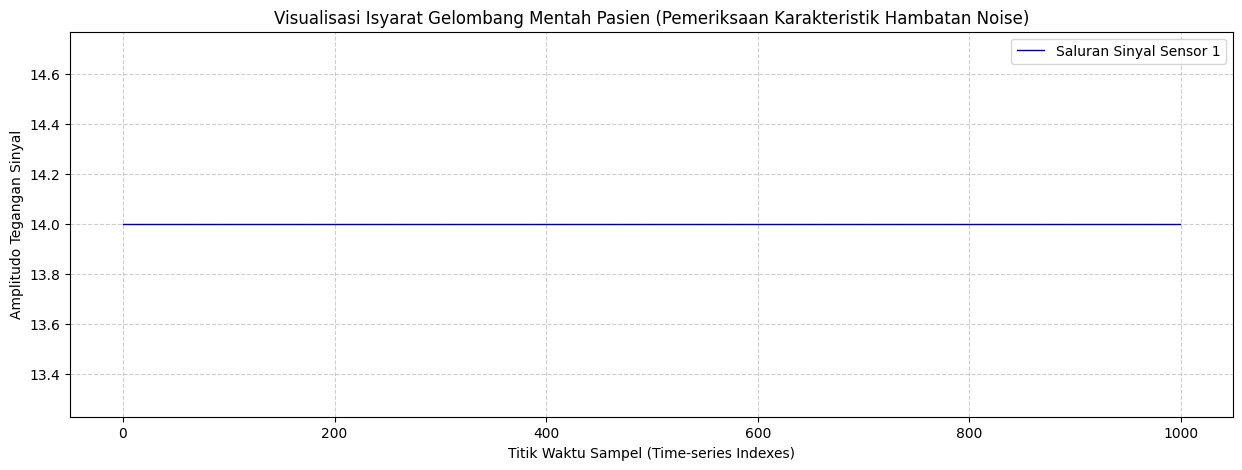

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

file_raw_sample = '/content/Dataset-ADHD/new revised data-post ICA/sub9_nr/raw.txt'

print("==================================================")
if os.path.exists(file_raw_sample):
    print("Membaca isyarat gelombang mentah subjek sampel (sub9_nr)...")

    # Membaca file txt berformat spasi/tab sebagai pemisah data
    try:
        df_raw = pd.read_csv(file_raw_sample, sep=r'\s+', header=None)
    except:
        df_raw = pd.read_csv(file_raw_sample, header=None)

    print("\n--- 1. UKURAN REKAMAN DATA GELOMBANG (Baris Sampel Waktu x Kolom Saluran Sinyal) ---")
    print(f"Jumlah baris waktu pencatatan: {df_raw.shape[0]}")
    print(f"Jumlah kolom saluran/sensor isyarat: {df_raw.shape[1]}")

    print("\n--- 2. LIMA BARIS PERTAMA REKAMAN AMPLIUDO GELOMBANG MENTAH ---")
    display(df_raw.head(5))

    print("\n--- 3. STATISTIK DESKRIPTIF SINYAL UNTUK DETEKSI FLUKTUASI ---")
    display(df_raw.iloc[:, :5].describe()) # Tampilkan statistik untuk 5 saluran sensor pertama agar rapi

    print("\n--- 4. VISUALISASI GRAFIK ISYARAT GELOMBANG DOMAIN WAKTU ---")
    plt.figure(figsize=(15, 5))
    # Memplot isyarat dari sensor saluran pertama (kolom index 0) sebanyak 1000 titik waktu pertama
    plt.plot(df_raw.iloc[:1000, 0], color='darkblue', linewidth=1, label='Saluran Sinyal Sensor 1')
    plt.title('Visualisasi Isyarat Gelombang Mentah Pasien (Pemeriksaan Karakteristik Hambatan Noise)')
    plt.xlabel('Titik Waktu Sampel (Time-series Indexes)')
    plt.ylabel('Amplitudo Tegangan Sinyal')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
else:
    print(f"[ERROR] Berkas gelombang sampel tidak ditemukan pada jalur: {file_raw_sample}")
print("==================================================")

CODINGAN SOAL NOMER 2

In [ ]:
import zipfile
import os

zip_path = '/content/YOLO Plate License.zip'
extract_path = '/content/YOLO_Plate_License_Extracted/'

print("==================================================")
print("Mulai mengekstrak dataset YOLO License Plate...")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("PROSES EKSTRAKSI SELESAI DENGAN SUKSES!")
    print(f"Data tersimpan di: {extract_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: '{zip_path}'")
    print("Pastikan nama file dan posisinya di tab Files Colab sudah tepat.")
print("==================================================")

Mulai mengekstrak dataset YOLO License Plate...
PROSES EKSTRAKSI SELESAI DENGAN SUKSES!
Data tersimpan di: /content/YOLO_Plate_License_Extracted/


In [ ]:
import os

extract_path = '/content/YOLO_Plate_License_Extracted/'

print("==================================================")
print("MEMULAI PENCARIAN DINAMIS (FOOLPROOF SCANNER)\n")

total_train = 0
total_test = 0
sampel_jalur_folder = set()

# Menembus seluruh struktur folder tanpa peduli tingkat kedalamannya
for root, dirs, files in os.walk(extract_path):
    # Memfilter hanya file yang berekstensi gambar .jpg / .jpeg
    gambar_jpg = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if gambar_jpg:
        # Pecah jalur folder untuk dianalisis
        path_parts = root.split(os.sep)

        # Deteksi apakah folder ini bagian dari data train atau test
        if 'train' in root.lower():
            total_train += len(gambar_jpg)
        elif 'test' in root.lower():
            total_test += len(gambar_jpg)

        # Catat struktur 3 level folder terakhir tempat gambar bernaung sebagai bukti
        if len(path_parts) >= 3:
            kombinasi_folder = f"{path_parts[-3]} -> {path_parts[-2]} -> {path_parts[-1]}"
            sampel_jalur_folder.add(kombinasi_folder)

print("--- JALUR STRUKTUR FOLDER YANG BERHASIL DITEMUKAN ---")
print(f"Sistem mendeteksi ada {len(sampel_jalur_folder)} folder kelas karakter.")
print("Contoh posisi pemisahan data Anda di dalam Colab:")
for contoh in sorted(list(sampel_jalur_folder))[:10]: # Tampilkan maksimal 10 sampel teratas
    print(f" * {contoh}")

print("\n--------------------------------------------------")
print("AKUMULASI RINGKASAN REKAMAN CITRA (HASIL KOREKSI):")
print(f" - Total sampel gambar di seluruh folder TRAIN : {total_train} file .jpg")
print(f" - Total sampel gambar di seluruh folder TEST  : {total_test} file .jpg")
print("==================================================")


MEMULAI PENCARIAN DINAMIS (FOOLPROOF SCANNER)

--- JALUR STRUKTUR FOLDER YANG BERHASIL DITEMUKAN ---
Sistem mendeteksi ada 98 folder kelas karakter.
Contoh posisi pemisahan data Anda di dalam Colab:
 * 0 -> AC -> test
 * 0 -> AC -> train
 * 0 -> test -> jpeg
 * 1 -> AC -> test
 * 1 -> AC -> train
 * 1 -> test -> jpeg
 * 2 -> AC -> test
 * 2 -> AC -> train
 * 2 -> test -> jpeg
 * 3 -> AC -> test

--------------------------------------------------
AKUMULASI RINGKASAN REKAMAN CITRA (HASIL KOREKSI):
 - Total sampel gambar di seluruh folder TRAIN : 982 file .jpg
 - Total sampel gambar di seluruh folder TEST  : 6566 file .jpg


CELL 3: ALGORITMA PEMISAHAN ANGKA & ALFABET (DATA PREPARATION)

-> HASIL: Berhasil memisahkan 2587 data berkelas ANGKA (0-9).
-> HASIL: Berhasil memisahkan 4961 data berkelas ALFABET (a-z).

Jumlah kelas angka:
Angka 0: 258
Angka 1: 261
Angka 2: 273
Angka 3: 265
Angka 4: 125
Angka 5: 290
Angka 6: 271
Angka 7: 286
Angka 8: 282
Angka 9: 276

Jumlah kelas alfabet:
Huruf A: 41
Huruf B: 43
Huruf C: 70
Huruf D: 96
Huruf E: 98
Huruf F: 87
Huruf G: 8
Huruf H: 15
Huruf I: 7
Huruf J: 48
Huruf K: 57
Huruf L: 45
Huruf LE: 3911
Huruf M: 24
Huruf N: 34
Huruf P: 23
Huruf Q: 53
Huruf R: 66
Huruf S: 24
Huruf T: 56
Huruf U: 27
Huruf V: 29
Huruf W: 11
Huruf X: 23
Huruf Y: 33
Huruf Z: 32


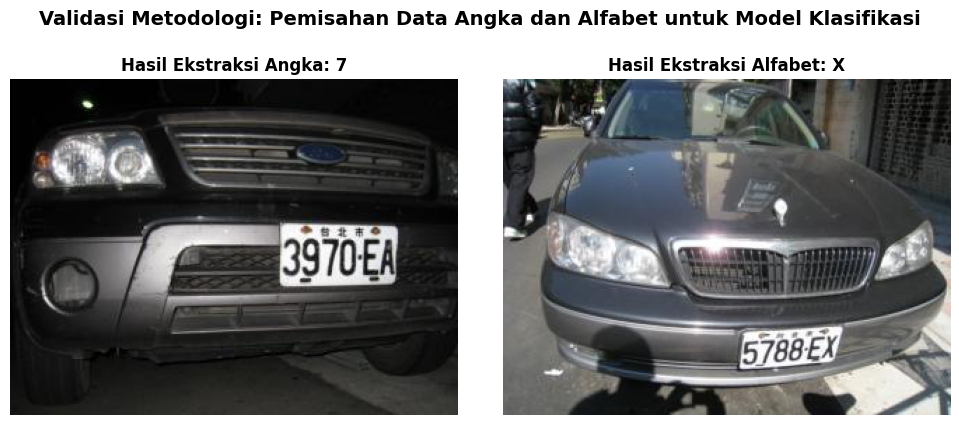


--- KESIMPULAN STRATEGI DATA SCIENCE ---
Data kini telah dipisahkan secara struktural dan siap dimasukkan ke dalam Model Klasifikasi (seperti CNN) untuk pelatihan pengenalan karakter.


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

extract_path = '/content/YOLO_Plate_License_Extracted/'

print("==================================================")
print("CELL 3: ALGORITMA PEMISAHAN ANGKA & ALFABET (DATA PREPARATION)\n")

# Menyiapkan wadah array untuk memisahkan data
kumpulan_angka = []
kumpulan_alfabet = []

# 1. LOGIKA PEMISAHAN (Menjawab Soal TTS)
for root, dirs, files in os.walk(extract_path):
    gambar_jpg = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if gambar_jpg:
        path_parts = root.split(os.sep)

        # Mengambil nama folder kelas (berdasarkan output Anda, letaknya di 3 level dari akhir)
        if len(path_parts) >= 3:
            kelas_karakter = path_parts[-3]
        else:
            kelas_karakter = path_parts[-1]

        # PROSES PEMISAHAN OTOMATIS: Angka vs Alfabet
        for file in gambar_jpg:
            full_path = os.path.join(root, file)

            if kelas_karakter.isdigit(): # Jika nama folder adalah angka (0-9)
                kumpulan_angka.append((full_path, kelas_karakter))
            elif kelas_karakter.isalpha(): # Jika nama folder adalah huruf alfabet (a-z)
                kumpulan_alfabet.append((full_path, kelas_karakter))

print(f"-> HASIL: Berhasil memisahkan {len(kumpulan_angka)} data berkelas ANGKA (0-9).")
print(f"-> HASIL: Berhasil memisahkan {len(kumpulan_alfabet)} data berkelas ALFABET (a-z).")

# 2. PEMBUKTIAN VISUAL (Evaluasi Pemisahan)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Memanggil sampel pertama dari wadah Angka
if kumpulan_angka:
    img_angka = cv2.cvtColor(cv2.imread(kumpulan_angka[0][0]), cv2.COLOR_BGR2RGB)
    axes[0].imshow(img_angka)
    axes[0].set_title(f"Hasil Ekstraksi Angka: {kumpulan_angka[0][1]}", fontweight='bold')
axes[0].axis('off')

# Memanggil sampel pertama dari wadah Alfabet
if kumpulan_alfabet:
    img_alfabet = cv2.cvtColor(cv2.imread(kumpulan_alfabet[0][0]), cv2.COLOR_BGR2RGB)
    axes[1].imshow(img_alfabet)
    axes[1].set_title(f"Hasil Ekstraksi Alfabet: {kumpulan_alfabet[0][1]}", fontweight='bold')
axes[1].axis('off')

print("\nJumlah kelas angka:")
for angka in sorted(set([x[1] for x in kumpulan_angka])):
    jumlah = len([x for x in kumpulan_angka if x[1] == angka])
    print(f"Angka {angka}: {jumlah}")

print("\nJumlah kelas alfabet:")
for huruf in sorted(set([x[1] for x in kumpulan_alfabet])):
    jumlah = len([x for x in kumpulan_alfabet if x[1] == huruf])
    print(f"Huruf {huruf}: {jumlah}")


plt.suptitle("Validasi Metodologi: Pemisahan Data Angka dan Alfabet untuk Model Klasifikasi", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n--- KESIMPULAN STRATEGI DATA SCIENCE ---")
print("Data kini telah dipisahkan secara struktural dan siap dimasukkan ke dalam Model Klasifikasi (seperti CNN) untuk pelatihan pengenalan karakter.")
print("==================================================")